In [3]:
import sys
sys.path.append("../../src")
import kibble_zurek as kz
import kblock_ising_model as kb
from common_imports import *

/Users/kristianmunnikhuis/Desktop/subsystem_loschmidt_echo/scripts/correlation_length_withN/../../src/kblock_ising_model.py:146: ComplexWarning: Casting complex values to real discards the imaginary part
  C[nx,ny] = D(Nd,T,k)


[]

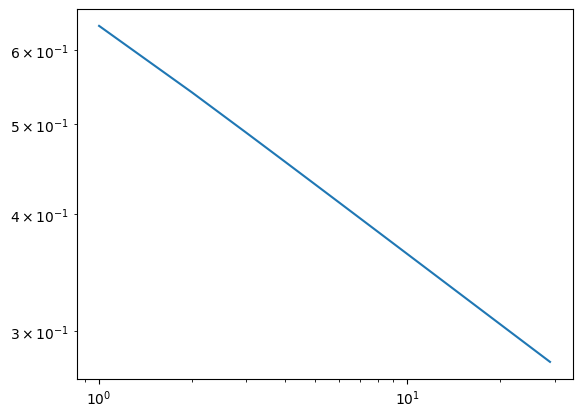

In [ ]:
k = kb.k_vals(1000)
g= 1
U = kb.U(k,g)

r = np.arange(1,30)
dat = [kb.sigma_general([0,ri],U,k) for ri in r]
plot(r,dat)



In [112]:
def D(n,g,T=0):


    def Dtilde(z,g,T):
        pf = sqrt((1-g*z)/(1-g/z))

        if T ==0:
            temp_term = 1
        else:
            temp_term = tanh(sqrt((1-g*z)*(1-g/z))/T)
        return pf*temp_term
    k = np.linspace(-pi,pi,1000,endpoint=False)

    z = exp(1j*k)
    phase = exp(-1j*n*k)

    return np.average(phase*Dtilde(z,g,T))


def sigma_general(indices,g,T=0):
    def remove_duplicates_in_pairs(vec):
      unique_vals, counts = np.unique(vec, return_counts=True)
      filtered_vals = unique_vals[counts % 2 != 0]
      return filtered_vals.tolist()
    #Sigma matrices on different sites commute
    indices = np.sort(indices)
    #Remove any duplicates as sigma_x^2 = 1
    indices = remove_duplicates_in_pairs(indices)
    #Bs sit on odd sites
    odd_sites = np.array(indices[::2])
    #As site on even sites
    even_sites= np.array(indices[1::2])
    #Get string lengths
    JW_string_lengths = even_sites-odd_sites
    #Sum of string lengths is size of matrix needed
    N = sum(JW_string_lengths)
    #Fill in indices for strings
    R = []
    for i in range(0, len(indices), 2):
        start = indices[i]
        end = indices[i+1]
        R.extend(range(start, end+1))

    A_coords = [x for x in R if x not in odd_sites]
    B_coords = [x for x in R if x not in even_sites]
    C = np.zeros((N,N),dtype=complex)
    for nx in range(N):
        for ny in range(N):
            Bx = B_coords[nx]
            Ay = A_coords[ny]
            Nd = Bx-Ay+1
            C[nx,ny] = D(Nd,g,T)
    return np.linalg.det(C)

        

[]

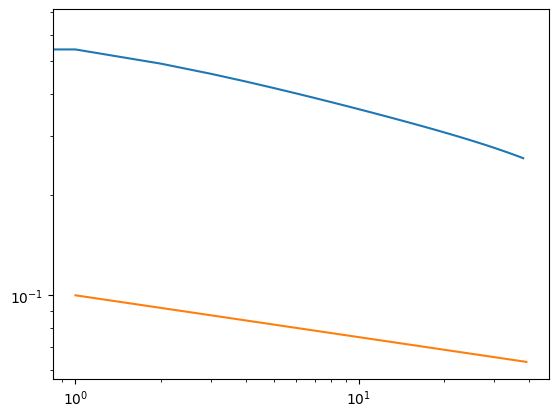